# Long-Short (Dollar-Neutral) Momentum — top/bottom 20%, monthly & weekly

Cross-sectional momentum traded **long-short**: each rebalance go **long the top 20%**
and **short the bottom 20%** by risk-adjusted 12-1 momentum, each leg summing to ±1
→ **net exposure 0, gross exposure 2×** before vol-targeting. The book is then scaled
to a **20% vol target** (gross leverage = 2 × the multiplier), so this section is
mainly about **how much leverage that takes** and whether the short leg adds anything.
Run at **monthly and weekly** rebalance.

> **Caveats up front.** (1) **Stock-borrow / short-financing costs are NOT modelled**
> — real long-short net returns would be lower. (2) Long-short momentum carries the
> classic **"momentum crash"** tail risk (losers rallying violently, e.g. 2009);
> watch the drawdowns. (3) Market-neutral, so the long-only S&P benchmark is not a
> fair comparison. Outputs in `results/long_short/`.

In [1]:
import warnings, os; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import momentum_strategies as ms
pd.set_option("display.float_format", lambda x: f"{x:,.3f}"); pd.set_option("display.max_columns", 40)
RES = "results/long_short"
for k in ["figures", "figure_data", "metrics", "weights"]: os.makedirs(f"{RES}/{k}", exist_ok=True)

md_m = ms.DataLoader("data").load()
md_w = ms.DataLoader("data", freq="W").load()
cost = ms.RealisticCostModel(fx_bps=15.0, aum=1e8)
MAXLEV, TOP_PCT = 3.0, 0.20        # multiplier cap -> gross capped at 2 x 3 = 6x; top/bottom 20%

def ls_cfg(ppy):
    return ms.StrategyConfig(kind="ls", top_pct=TOP_PCT, weighting="equal", target_vol=0.20,
        max_leverage=MAXLEV,
        lookback=52 if ppy == 52 else 12, gap=4 if ppy == 52 else 1,
        vol_window=52 if ppy == 52 else None,
        vol_lookback=26 if ppy == 52 else 6, vol_halflife=17.0 if ppy == 52 else 4.0)

variants = {"monthly": (md_m, 12, ls_cfg(12)), "weekly": (md_w, 52, ls_cfg(52))}
print("variants:", list(variants), "| top/bottom", f"{TOP_PCT:.0%}")

variants: ['monthly', 'weekly'] | top/bottom 20%


## 1. Construction check — long top 20%, short bottom 20%, net ≈ 0

Current (latest-rebalance) book for the monthly variant: positive weights are longs,
negative are shorts; they net to ~0 and gross to ~2× the vol-target multiplier.

In [2]:
results = {}
for nm, (mkt, ppy, cfg) in variants.items():
    res = ms.Backtester(mkt, cost, ppy).run(ms.build_signal(mkt, cfg), cfg)
    results[nm] = res
    ms.save_weights(res, f"{RES}/weights/{nm}_ls20", sectors=mkt.sectors)

cur = results["monthly"].current_weights()
book = pd.concat([cur.head(5).rename("weight"), cur.tail(5).rename("weight")])
print("monthly — top 5 longs and bottom 5 shorts (of the current book):")
display(book.to_frame().assign(side=np.where(book > 0, "LONG", "SHORT")).round(4))
print("names: %d long, %d short | net exposure %.3f | gross exposure %.2fx" % (
    (cur > 0).sum(), (cur < 0).sum(), cur.sum(), cur.abs().sum()))

monthly — top 5 longs and bottom 5 shorts (of the current book):


,weight,side
symbol,,
AAPL,0.013,LONG
GS,0.013,LONG
GOOGL,0.013,LONG
GOOG,0.013,LONG
GNRC,0.013,LONG
EFX,-0.013,SHORT
DPZ,-0.013,SHORT
DIS,-0.013,SHORT
DASH,-0.013,SHORT


names: 96 long, 96 short | net exposure 0.000 | gross exposure 2.49x


## 2. Statistics & leverage (the headline)

Full metrics for both variants. **Gross leverage** = mean / max of |long| + |short|
(net is ~0, so it's not the usual "% invested"); **unlevered vol** is the vol of the
raw gross-2 book — the gap to 20% is what the leverage has to close.

In [3]:
rows = {}
for nm, res in results.items():
    m = ms.metrics_from_result(res)
    base = ms.compute_metrics(res.base_returns, periods_per_year=res.periods_per_year)  # unlevered gross-2 book
    rows[nm] = {
        "Sharpe": m["Sharpe"], "Sortino": m["Sortino"], "CAGR": m["CAGR"], "Ann.Vol": m["Ann.Vol"],
        "MaxDrawdown": m["MaxDrawdown"], "Calmar": m["Calmar"], "WinRate": m["WinRate"],
        "ProfitFactor": m["ProfitFactor"], "Skewness": m["Skewness"], "AnnTurnover": m["AnnTurnover"],
        "AnnTCost": m["AnnTCost"], "GrossLev(mean)": res.leverage.mean(), "GrossLev(max)": res.leverage.max(),
        "NetExposure": res.weights.sum(axis=1).mean(), "UnlevVol": base["Ann.Vol"],
    }
tbl = pd.DataFrame(rows)
tbl.to_csv(f"{RES}/metrics/long_short_metrics.csv")
print("Long-short momentum, top/bottom 20% (net of FX/spread/impact; borrow NOT modelled):")
display(tbl.round(3))

Long-short momentum, top/bottom 20% (net of FX/spread/impact; borrow NOT modelled):


,monthly,weekly
Sharpe,-0.015,0.242
Sortino,-0.021,0.298
CAGR,-0.023,0.028
Ann.Vol,0.202,0.194
MaxDrawdown,-0.678,-0.262
Calmar,-0.034,0.108
WinRate,0.478,0.394
ProfitFactor,0.988,1.108
Skewness,-0.122,-0.280
AnnTurnover,10.379,17.902


## 3. Leverage through time & growth of \$1

The dollar-neutral book runs gross leverage that rises when the long-short *spread*
is calm and falls when it is volatile (the vol-target). Growth of \$1 shows whether
the short leg earns its keep.

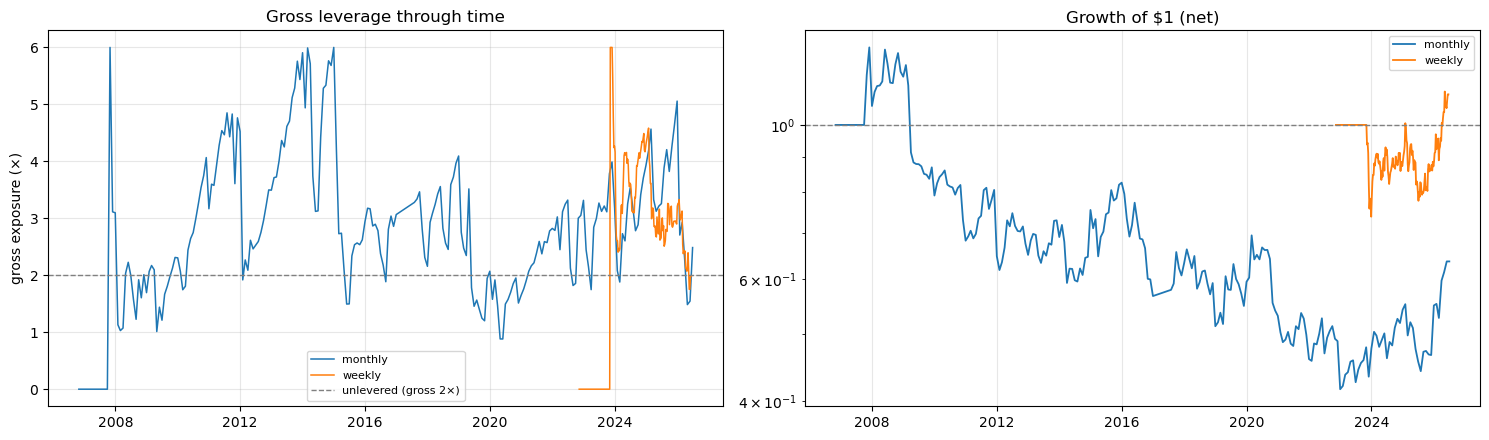

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
for nm, res in results.items():
    ax[0].plot(res.leverage.index, res.leverage.values, label=nm, lw=1.1)
    eq = res.equity("net"); ax[1].plot(eq.index, eq.values, label=nm, lw=1.3)
ax[0].axhline(2.0, ls="--", color="grey", lw=1, label="unlevered (gross 2×)")
ax[0].set_title("Gross leverage through time"); ax[0].set_ylabel("gross exposure (×)"); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
ax[1].axhline(1.0, ls="--", color="grey", lw=1); ax[1].set_yscale("log")
ax[1].set_title("Growth of $1 (net)"); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
pd.DataFrame({nm: res.leverage for nm, res in results.items()}).to_csv(f"{RES}/figure_data/leverage.csv")
pd.DataFrame({nm: res.equity("net") for nm, res in results.items()}).to_csv(f"{RES}/figure_data/growth.csv")
fig.savefig(f"{RES}/figures/leverage_and_growth.png", dpi=120, bbox_inches="tight"); plt.tight_layout(); plt.show()

## 4. Dashboard — monthly

2×3 dashboard for the monthly book (the benchmark panel is the long-only index,
shown for reference only — this strategy is market-neutral). The drawdown panel
exposes the **2009 momentum crash**.

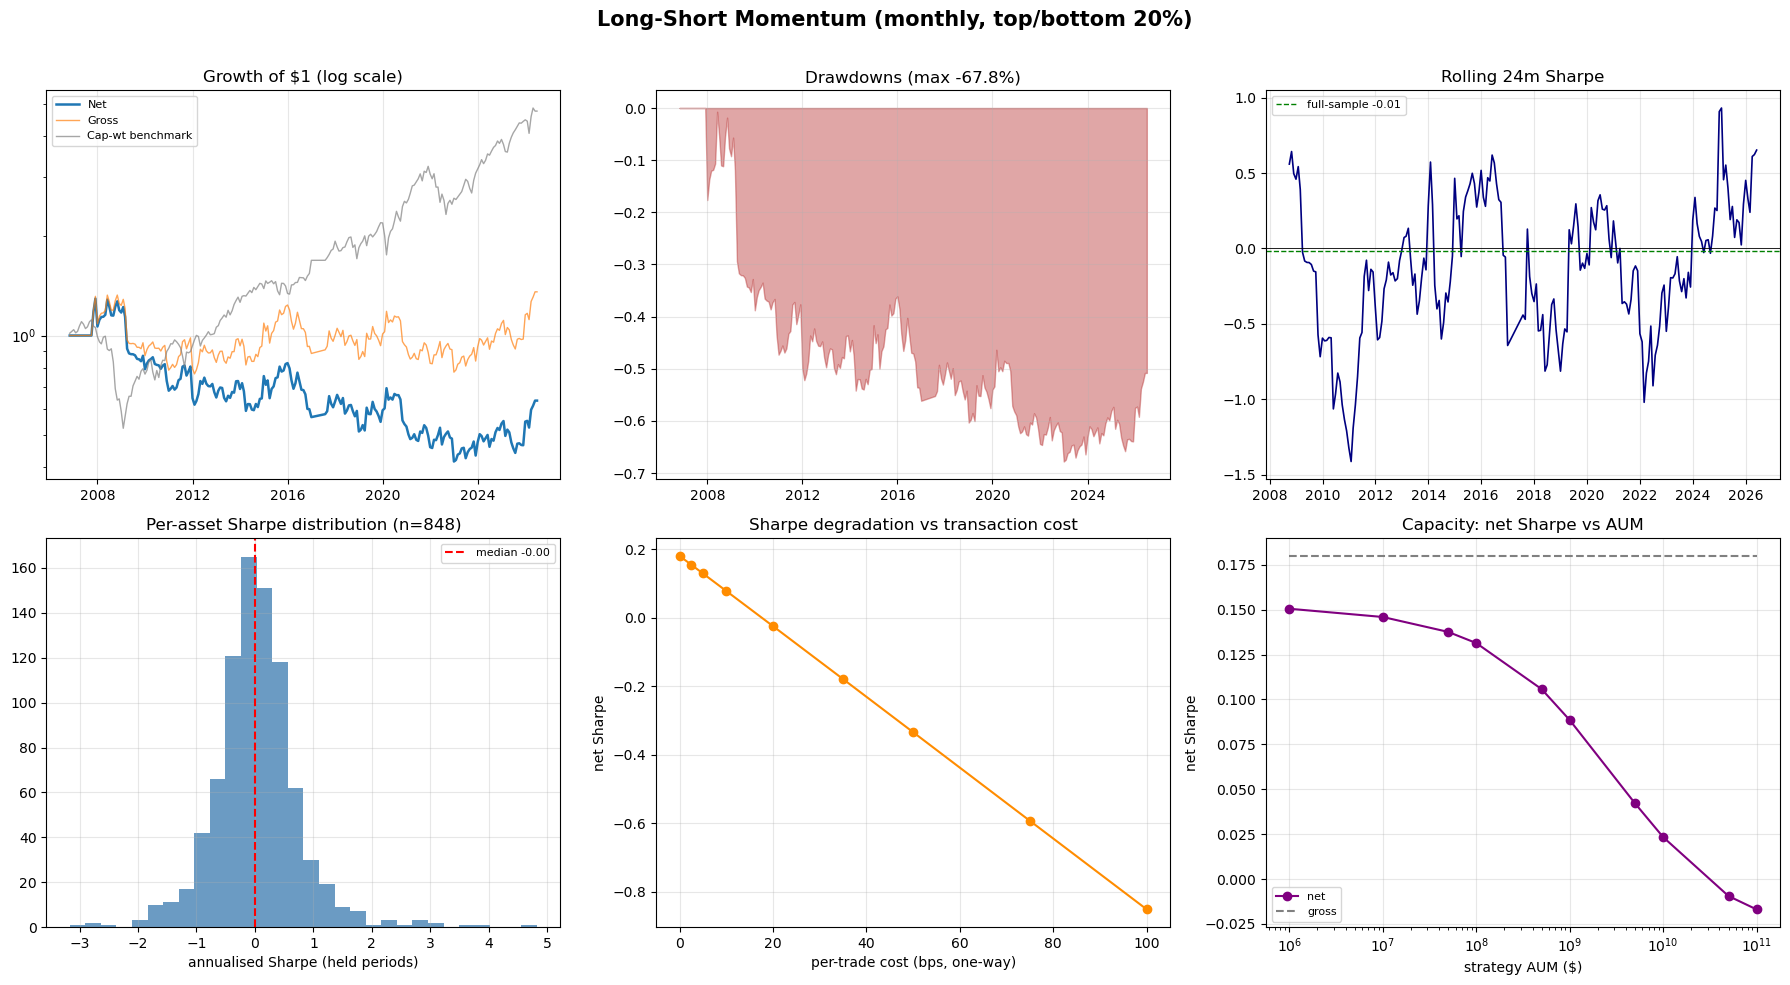

In [5]:
sig_m = ms.build_signal(md_m, variants["monthly"][2])
ms.plot_strategy_dashboard(results["monthly"], md_m, sig_m,
    "Long-Short Momentum (monthly, top/bottom 20%)",
    fig_path=f"{RES}/figures/ls_monthly_dashboard.png", data_dir=f"{RES}/figure_data",
    slug="ls_monthly"); plt.show()

## 5. Conclusions

* **Leverage.** Dollar-neutral (net ≈ 0). To hit 20% vol the top/bottom-20% book runs
  **~2.4–2.8× gross on average, spiking to the 6× cap** in calm-spread regimes —
  because the long-short *spread* is low-vol (unlevered ~12–15%).
* **Performance.** The short leg does **not** earn its keep in S&P large-caps:
  **monthly** long-short is roughly **flat-to-negative (Sharpe ≈ 0)** with a
  **catastrophic ~−68% drawdown** from the 2009 momentum crash (losers rallying).
  This is the flip side of the long-only result — the edge was *avoiding* losers, but
  *shorting* large-cap losers loses money and blows up in crashes. **Cost drag alone is
  ~4%/yr** (both legs, levered, FX-heavy), before any borrow fees.
* **Weekly** (short 2022-11+ sample, no 2009 crash) is mildly positive but weak
  (Sharpe ~0.2) — indicative only.
* **Bottom line.** Long-short momentum here is a **levered, crash-prone, ~zero-edge**
  book before borrow costs (which would push it further negative). The long-only /
  trend-filtered books remain the better expression of this signal.